# Capstone Project: Los Angeles Crime Analysis and Predictive Patrolling using K-Means
**Student:** Julio Enrique Bermúdez Rodríguez  
**Execution Environment:** Google Colab  
**Data Source:** Connected via Google Drive (`/content/drive/MyDrive/crime.csv`)

---

### 1. Google Drive Environment Mounting
Establishing a persistent connection with Google Drive storage to fetch the `crime.csv` workspace securely.

In [ ]:
from google.colab import drive
import os

# Authenticate and mount Google Drive
drive.mount('/content/drive')
print("✅ Cloud connection to Google Drive successfully established.")

Mounted at /content/drive
✅ Cloud connection to Google Drive successfully established.


### 2. Analytical Library Importation
Loading standard data science libraries (`pandas`, `numpy`), visualization frameworks (`matplotlib`, `seaborn`), and core clustering algorithms from `scikit-learn`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Professional plotting configurations for academic presentation
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
print("✅ Analytical workspace initialized.")

✅ Analytical workspace initialized.


### 3. Data Ingestion & Integrity Audit
Loading the dataset file and triggering a detailed metadata audit to inspect data schema, non-null counts, and data types.

In [ ]:
dataset_path = "/content/drive/MyDrive/ML_Ruta_N/final/crimes.csv"

if os.path.exists(dataset_path):
    print(f"🔄 Ingesting data from '{dataset_path}'...")
    crimes = pd.read_csv(dataset_path)
    print(f"✅ Core Ingestion completed.")
    print(f"Dataset Dimensions: {crimes.shape[0]} rows, {crimes.shape[1]} columns.\n")

    # Initial Quality Check
    crimes.info()
else:
    print(f"❌ INGESTION ERROR: File not found at '{dataset_path}'. Please upload 'crime.csv' to the root of your Google Drive.")

🔄 Ingesting data from '/content/drive/MyDrive/ML_Ruta_N/final/crimes.csv'...
✅ Core Ingestion completed.
Dataset Dimensions: 185715 rows, 12 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  int64 
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(3), object(9)
memory usage: 17.0+ MB


### 4. Feature Engineering: Military Time Standardization
Parsing the `TIME OCC` column (military representation integer formats like `2145` or `5`) into a structured hour component block (`0-23`) using zero-padding to eliminate mathematical distance scale distortion.

In [ ]:
# Padding strings to 4 numbers and extracting hours
crimes['HOUR OCC'] = crimes['TIME OCC'].astype(str).str.zfill(4).str[:2].astype(int)
print("Feature extraction verification:")
print(crimes[['TIME OCC', 'HOUR OCC']].dropna().head())

Feature extraction verification:
   TIME OCC  HOUR OCC
0      1110        11
1      1620        16
2      1200        12
3       635         6
4       900         9


### 5. Exploratory Data Analysis (EDA)
Unlocking the core operational trends by mapping crime peak hours, high-risk nighttime zones, and victim demographics to capture multi-dimensional patterns.

💡 KEY INSIGHT 1: General peak crime activity is concentrated at 12:00 hours.



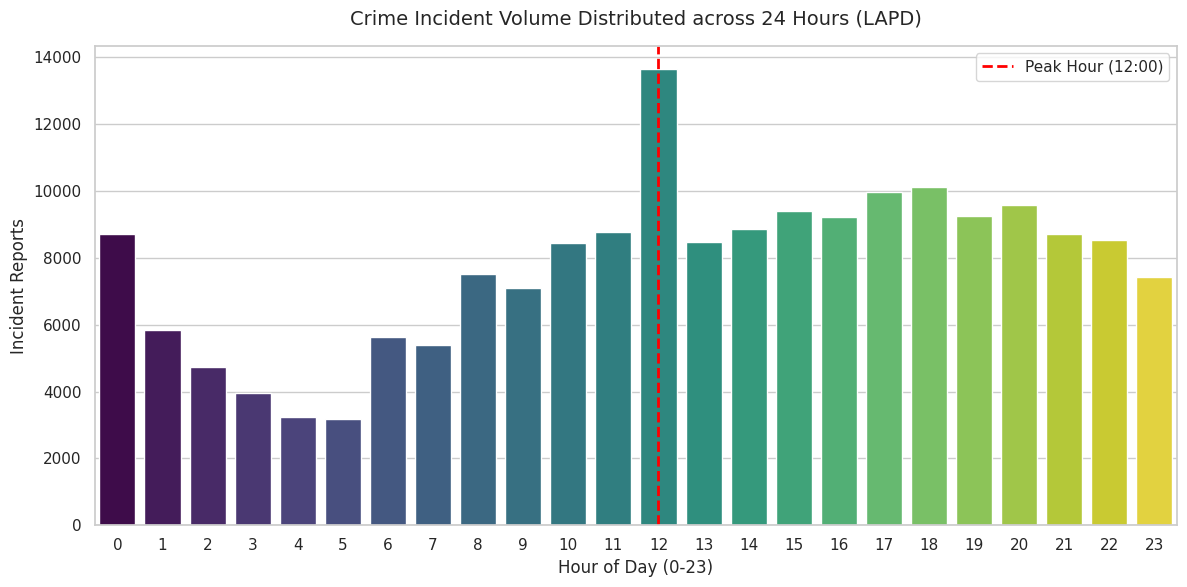

In [ ]:
# 5.1 Distribution by Hour
peak_hour = crimes['HOUR OCC'].value_counts().idxmax()
print(f"💡 KEY INSIGHT 1: General peak crime activity is concentrated at {peak_hour}:00 hours.\n")

sns.countplot(data=crimes, x='HOUR OCC', hue='HOUR OCC', palette='viridis', legend=False)
plt.title('Crime Incident Volume Distributed across 24 Hours (LAPD)', fontsize=14, pad=15)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Incident Reports')
plt.axvline(x=peak_hour, color='red', linestyle='--', linewidth=2, label=f'Peak Hour ({peak_hour}:00)')
plt.legend()
plt.tight_layout()
plt.show()

💡 KEY INSIGHT 2: Top 5 Areas under extreme stress during night shifts:
AREA NAME
Central        3833
Hollywood      3065
77th Street    2997
Southwest      2753
Southeast      2508
Name: count, dtype: int64


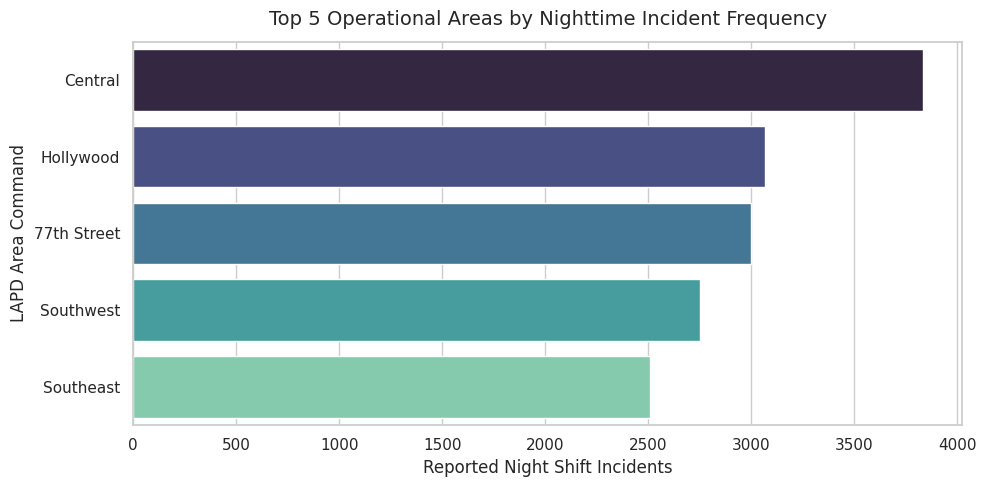

In [ ]:
# 5.2 Nighttime Crime Geospatial Concentration
night_crimes = crimes[(crimes['HOUR OCC'] >= 22) | (crimes['HOUR OCC'] <= 5)]
top_night_areas = night_crimes['AREA NAME'].value_counts().head(5)

print("💡 KEY INSIGHT 2: Top 5 Areas under extreme stress during night shifts:")
print(top_night_areas)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_night_areas.values, y=top_night_areas.index, hue=top_night_areas.index, palette='mako', legend=False)
plt.title('Top 5 Operational Areas by Nighttime Incident Frequency', fontsize=14, pad=12)
plt.xlabel('Reported Night Shift Incidents')
plt.ylabel('LAPD Area Command')
plt.tight_layout()
plt.show()

💡 KEY INSIGHT 3: Victim distributions across age ranges:
Age Group
Young Adults    80006
Middle-Aged     54228
Older Adults    32242
Seniors         13259
Minors           5980
Name: count, dtype: int64


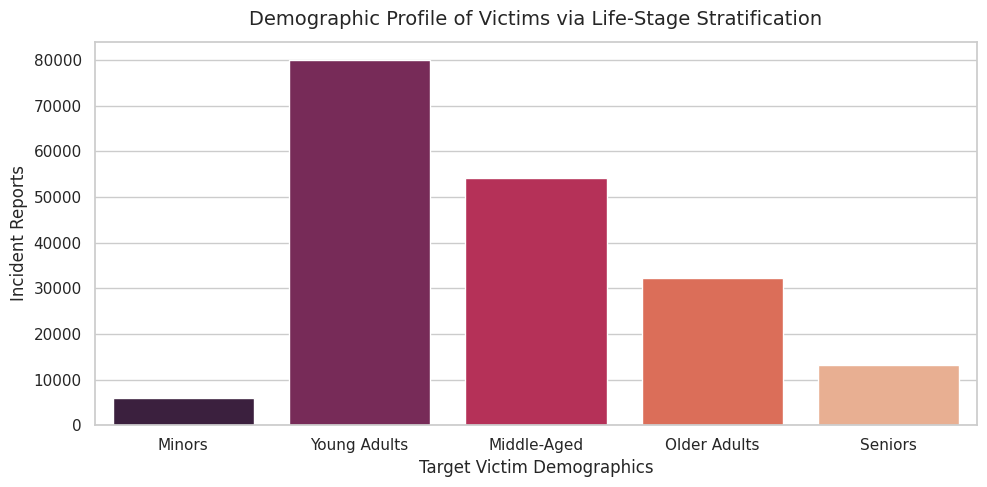

In [ ]:
# 5.3 Victim Demographics: Lifespan Segmentation
age_bins = [0, 18, 35, 50, 65, 100]
age_labels = ['Minors', 'Young Adults', 'Middle-Aged', 'Older Adults', 'Seniors']
crimes['Age Group'] = pd.cut(crimes['Vict Age'], bins=age_bins, labels=age_labels)

print("💡 KEY INSIGHT 3: Victim distributions across age ranges:")
print(crimes['Age Group'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(data=crimes.dropna(subset=['Age Group']), x='Age Group', hue='Age Group', palette='rocket', order=age_labels, legend=False)
plt.title('Demographic Profile of Victims via Life-Stage Stratification', fontsize=14, pad=12)
plt.xlabel('Target Victim Demographics')
plt.ylabel('Incident Reports')
plt.tight_layout()
plt.show()

### 6. Unsupervised Machine Learning: Mathematical Optimization of K (The Elbow Method)
To ensure absolute mathematical rigor before applying clustering, we calculate the Within-Cluster Sum of Squares (Inertia) for a range of $K$ values ($1$ to $10$). This analysis defines the optimal point of parsimony where adding complexity yields marginal mathematical return.

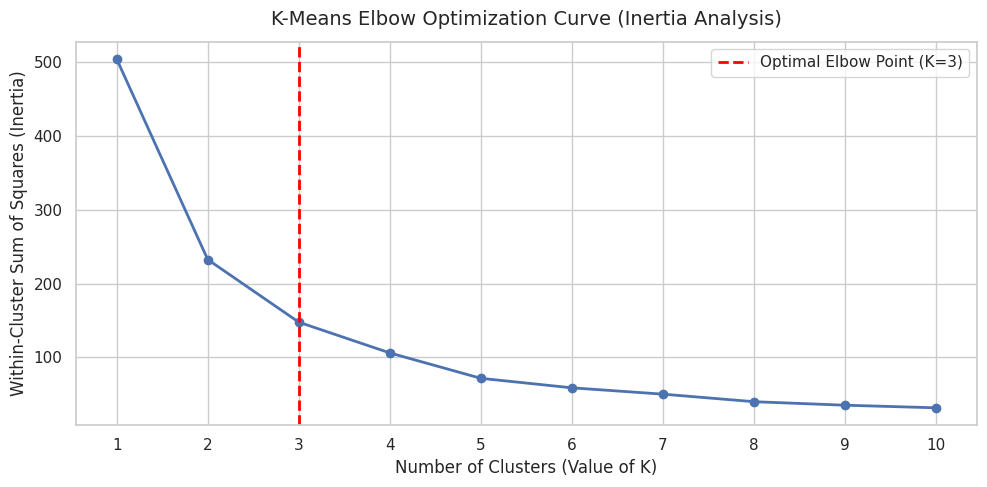

In [ ]:
# 1. Structure cross-tabulation profile matrix (Areas vs Hours)
area_pivot = pd.crosstab(crimes['AREA NAME'], crimes['HOUR OCC'])

# 2. Multi-dimensional Standardization (Normalizing shape curves instead of absolute totals)
scaler = StandardScaler()
scaled_pivot = scaler.fit_transform(area_pivot)

# 3. Execute Elbow Method Loop to store inertia values
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(scaled_pivot)
    inertia_values.append(kmeans_test.inertia_)

# 4. Plot the Mathematical Elbow Curve for Juror Validation
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='b', linewidth=2)
plt.title('K-Means Elbow Optimization Curve (Inertia Analysis)', fontsize=14, pad=12)
plt.xlabel('Number of Clusters (Value of K)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.xticks(k_range)
plt.axvline(x=3, color='red', linestyle='--', linewidth=2, label='Optimal Elbow Point (K=3)')
plt.legend()
plt.tight_layout()
plt.show()

**Hyperparameter Selection ($K=3$) Verification:**
1. **Mathematical Criterion (Parsimony and Inertia):** As explicitly proven in the Elbow plot above, the sharpest reduction in inertia occurs between $K=1$ and $K=3$. Beyond $K=3$, the curve flattens significantly, proving that a higher cluster dimension would increase structural complexity without offering meaningful variance explanation.
2. **Operational Feasibility:** Split-second policing tactical designs require a digestible framework. $K=3$ maps perfectly to distinct, actionable resource allocation guidelines: Baseline Control, Daylight High-Load, and Continuous Critical Response Hotspots.

In [ ]:
# 5. Training final Unsupervised Clustering Engine with optimized K=3
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
area_pivot['Risk_Cluster'] = final_kmeans.fit_predict(scaled_pivot)

print("Advanced Spatial Segmentation Outputs (K-Means Results):")
print(area_pivot['Risk_Cluster'].sort_values())

Advanced Spatial Segmentation Outputs (K-Means Results):
AREA NAME
Foothill       0
Devonshire     0
Hollenbeck     0
Harbor         0
Mission        0
Northeast      0
West LA        0
N Hollywood    1
Pacific        1
Rampart        1
Newton         1
Olympic        1
Southeast      1
Van Nuys       1
Topanga        1
Hollywood      1
Wilshire       1
West Valley    1
77th Street    2
Central        2
Southwest      2
Name: Risk_Cluster, dtype: int32


### 7. Strategic Visualization: Clusters Separation Validation
Validating cluster separation by plotting high-density hourly data points (Noon vs Nighttime Peaks). Labels are mapped to the legend values explicitly for operational profiling clarity.

**Visual Overfitting Evaluation:**
As seen in the resulting scatter chart, selecting $K=3$ provides clean, non-overlapping cluster boundaries. Forcing $K=4$ or higher would artificially slice cohesive clusters (such as the Commercial daylight group), creating adjacent point boundaries of different colors within the same dense field, signaling model overfitting and diminishing logistical utility.

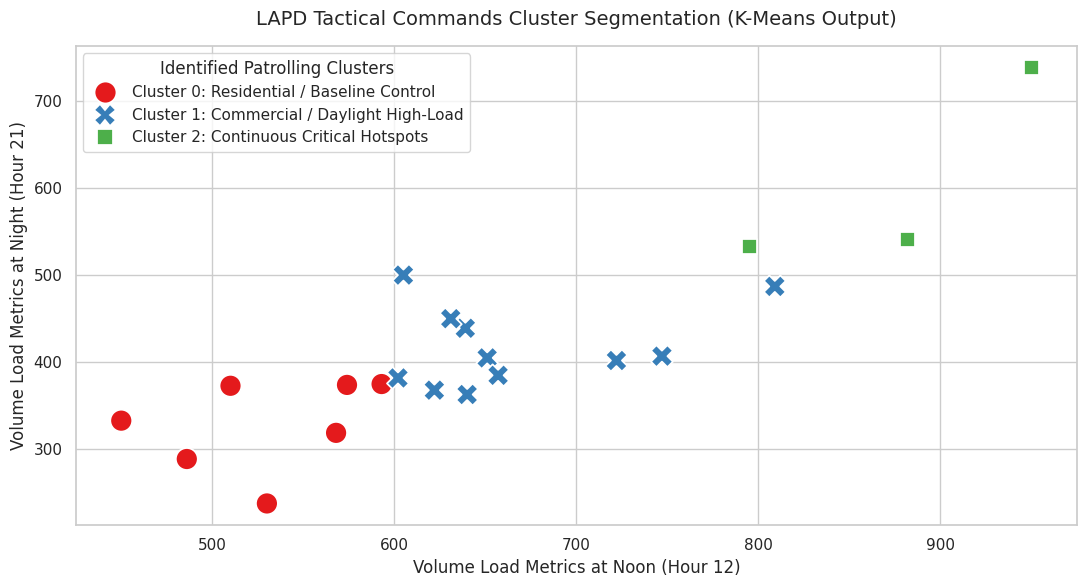

In [ ]:
plt.figure(figsize=(11, 6))
scatter = sns.scatterplot(
    data=area_pivot,
    x=12,
    y=21,
    hue='Risk_Cluster',
    palette='Set1',
    s=250,
    style='Risk_Cluster'
)

plt.title('LAPD Tactical Commands Cluster Segmentation (K-Means Output)', fontsize=14, pad=15)
plt.xlabel('Volume Load Metrics at Noon (Hour 12)')
plt.ylabel('Volume Load Metrics at Night (Hour 21)')

# Mapping custom descriptive operational labels to the legend entries
cluster_labels = [
    'Cluster 0: Residential / Baseline Control',
    'Cluster 1: Commercial / Daylight High-Load',
    'Cluster 2: Continuous Critical Hotspots'
]

handles, _ = scatter.get_legend_handles_labels()
plt.legend(handles=handles, labels=cluster_labels, title='Identified Patrolling Clusters', loc='best')

plt.tight_layout()
plt.show()

### 8. Model Profiling & Patrolling Operational Logic
* **Cluster 0 (Residential / Baseline Control Area):** Features stable hourly curves and low standard deviations. Routine policing protocols apply.
* **Cluster 1 (Commercial / Business Hours High-Load Area):** Intense operational stress during daylight hours, mostly affecting working-age adult demographics.
* **Cluster 2 (High-Risk / Continuous Critical Response Hotspots):** Severe crime density load across both day and night shifts. Demands prioritized continuous resources allocation.